## Spike analysis for Neuropixels 2.0 - Open Ephys streams - multiprobe
###### NB not yet tested with NP 1.0 or with single probes
###### Mar 03, 2026

### Import packages 

In [1]:
# spikeinterface

import spikeinterface.full as si
import spikeinterface.preprocessing as sp   
# from spikeinterface.preprocessing import bandpass_filter, common_reference, phase_shift, remove_artifacts
import spikeinterface.widgets as sw

from spikeinterface.sorters import installed_sorters
from spikeinterface.sorters import get_default_sorter_params, get_sorter_params_description

from spikeinterface.sorters import run_sorter as ss
from spikeinterface.sorters import Kilosort4Sorter as ks

from spikeinterface.curation import apply_sortingview_curation  # optional
from spikeinterface.postprocessing import compute_principal_components
import spikeinterface.qualitymetrics as sqm

# probe
from probeinterface.plotting import plot_probe
from probeinterface import write_probeinterface, read_probeinterface
from probeinterface import ProbeGroup, write_prb, read_prb

# kilosort
import kilosort
from kilosort import io
from kilosort import run_kilosort, DEFAULT_SETTINGS
from kilosort.io import load_probe

# curation
import spikeinterface.curation as sc
# pip install huggingface_hub ## if not already installed in your environment
import huggingface_hub # import the classifier repo

# view traces
import ephyviewer

# extras
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re
import os
import json
from itertools import product
import datetime # Get the current time 
import psutil # forces to kill processes
from matplotlib.colors import LinearSegmentedColormap

# Custom LFP colormap: green – white – purple (used for LFP map visualisation)
GWPmap = LinearSegmentedColormap.from_list(
    'BlueWhiteYellow',
    [
        (0.0, "#A1D76A"),
        (0.5, '#ffffff'),
        (1.0, "#CE6AD7")
    ],
    N=256
)

# sanity check for versions and availability of sorters
print("SpikeInterface version:", si.__version__)
print("Kilosort version:", kilosort.__version__)
print("Huggingface Hub version:", huggingface_hub.__version__)
# check which sorters are installed and get kilosort4 default parameters and descriptions
print(installed_sorters())
# kilosort4 is available as a sorter in spikeinterface, but it is not installed by default. You need to install it separately and make sure it is in your system path for spikeinterface to find it. If you have it installed, you can check its version and get its default parameters and descriptions as follows:
# print(ss.get_sorter_version("kilosort4"))
params = get_default_sorter_params(sorter_name_or_class='kilosort4')
print("Parameters:\n", params)

desc = get_sorter_params_description(sorter_name_or_class='kilosort4')
print("Descriptions:\n", desc)

# check widget backend
# sw.set_default_plotter_backend(backend="ipywidgets")
sw.set_default_plotter_backend(backend="matplotlib")
# activate the widget backend for interactive plotting in Jupyter notebooks
# %matplotlib widget
print(sw.get_default_plotter_backend())


def detect_artifact_periods_by_envelope_manual(
    recording,
    threshold_std=7.0,
    min_distance_s=0.25,
    max_inspect_s=60.0,
    window_before_s=0.01,
    window_after_s=0.02,
    n_channels=32,
):
    """Simple artifact period detector using a trace envelope on a subset of channels."""
    fs = recording.get_sampling_frequency()
    num_samples = recording.get_num_samples(segment_index=0)
    duration_s = num_samples / fs
    n_channels = min(n_channels, recording.get_num_channels())
    channel_ids = recording.channel_ids[:n_channels]
    end_frame = min(int(fs * max_inspect_s), num_samples)
    traces = recording.get_traces(segment_index=0, start_frame=0, end_frame=end_frame, channel_ids=channel_ids)
    env = np.max(np.abs(traces), axis=1)
    med = np.median(env)
    mad = np.median(np.abs(env - med))
    threshold = med + threshold_std * max(mad, 1.0)
    above = np.where(env > threshold)[0]
    if len(above) == 0:
        return []
    gaps = np.diff(above)
    splits = np.where(gaps > int(min_distance_s * fs))[0] + 1
    event_groups = np.split(above, splits)
    periods = []
    for group in event_groups:
        if len(group) == 0:
            continue
        peak_frame = group[0]
        start = max(0.0, peak_frame / fs - window_before_s)
        stop = min(duration_s, peak_frame / fs + window_after_s)
        periods.append((start, stop))
    return periods


C:\Users\Andrea\AppData\Local\Temp\ipykernel_28540\469645252.py:16: DeprecationWarning: The module 'spikeinterface.qualitymetrics' is deprecated and will be removed in 0.105.0.Please use 'spikeinterface.metrics.quality' instead.
  import spikeinterface.qualitymetrics as sqm


SpikeInterface version: 0.104.1
Kilosort version: 4.1.5
Huggingface Hub version: 1.4.1
['kilosort4', 'lupin', 'simple', 'spykingcircus2', 'tridesclous2']
Parameters:
 {'batch_size': 60000, 'nblocks': 1, 'Th_universal': 9, 'Th_learned': 8, 'nt': 61, 'shift': None, 'scale': None, 'batch_downsampling': 1, 'artifact_threshold': inf, 'nskip': 25, 'whitening_range': 32, 'highpass_cutoff': 300, 'binning_depth': 5, 'sig_interp': 20, 'drift_smoothing': [0.5, 0.5, 0.5], 'nt0min': None, 'dmin': None, 'dminx': 32, 'min_template_size': 10, 'template_sizes': 5, 'nearest_chans': 10, 'nearest_templates': 100, 'max_channel_distance': 32, 'max_peels': 100, 'templates_from_data': True, 'n_templates': 6, 'n_pcs': 6, 'Th_single_ch': 6, 'acg_threshold': 0.2, 'ccg_threshold': 0.25, 'cluster_neighbors': 10, 'cluster_downsampling': 20, 'max_cluster_subset': 25000, 'x_centers': None, 'cluster_init_seed': 5, 'duplicate_spike_ms': 0.25, 'position_limit': 100, 'do_CAR': True, 'invert_sign': False, 'save_extra_vars

### Find dirs for the main loop

In [3]:
root_directory  = os.path.normpath(r"I:\Neuropixels_Backup\Agata")
dest_path       = os.path.normpath(r'X:\Agata_spikesorted') 
now             = datetime.datetime.now() # Format the time as YYYYMMDDHHMM 
formatted_time  = now.strftime('%Y%m%d%H%M')

# Initialize a dictionary to store the 1st and 2nd level directories
folders         = {1: []}

# Walk through the directory tree
for dirpath, dirnames, filenames in os.walk(root_directory):
    
    # Calculate the level (relative to root_directory)
    level = os.path.normpath(dirpath).replace(root_directory, "").strip(os.sep).count(os.sep) + 1

    # Store only the first two levels
    if level in folders:
        folders[level].extend([os.path.join(dirpath, d) for d in dirnames])

max_depth = max(len(path.split(os.sep)) for path in folders[1])
folders2 = [path for path in folders[1] if len(path.split(os.sep)) == max_depth]

# filter only ####-##-##_##-##-## folders using regexp
pattern = r"\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}"
folders2 = [path for path in folders2 if re.search(pattern, os.path.basename(path))]
# if any item in the list folder2 contains the substring "_test" in its name, remove it from the list
folders2 = [p for p in folders2 if "_test" not in str(p).lower()]

# Print folders as a vertical column with index
print(f"\nFound {len(folders2)} recordings:\n")
for i, folder in enumerate(folders2, 1):
    print(f"  {i}. {folder}")


Found 10 recordings:

  1. I:\Neuropixels_Backup\Agata\20250311_Agata_VNS_N2_happy\2025-03-11_14-25-44
  2. I:\Neuropixels_Backup\Agata\20250604_Agata_VNS_C3_stress\2025-06-04_11-52-52
  3. I:\Neuropixels_Backup\Agata\20250520_Agata_VNS_C1_stress\2025-05-20_12-52-33
  4. I:\Neuropixels_Backup\Agata\20250520_Agata_VNS_C2_stress\2025-05-20_17-24-24
  5. I:\Neuropixels_Backup\Agata\20250606_Agata_VNS_C4_stress\2025-06-06_12-14-46
  6. I:\Neuropixels_Backup\Agata\20250331_Agata_VNS_N4_happy\2025-03-31_17-50-25
  7. I:\Neuropixels_Backup\Agata\20250331_Agata_VNS_N3_happy\2025-03-31_12-55-04
  8. I:\Neuropixels_Backup\Agata\20250305_Agata_VNS_N1_happy\2025-03-05_13-14-55
  9. I:\Neuropixels_Backup\Agata\20251219_Agata_VNS_N5_happy\2025-12-19_12-15-05
  10. I:\Neuropixels_Backup\Agata\20251219_Agata_VNS_N6_happy\2025-12-19_16-06-59


In [11]:
# # import spikeinterface.extractors as se

# folder_path = r"I:\Neuropixels_Backup\IDO1\20260219_ET1_rec1\2026-02-19_15-55-40"

# # List available streams
# streams = si.get_neo_streams('openephysbinary', folder_path)
# blocks = si.get_neo_num_blocks('openephysbinary', folder_path)
# print("Available blocks:", blocks)
# print("Available streams:", streams)
# # using regexp extract all the 'Probe' type (ProbeA, ProbeB) from streams (e.g. 'Record Node 101#Neuropix-PXI-100.ProbeA')
# stream_names, stream_ids = streams
# probes = [re.search(r'Probe\w+', n).group() for n in stream_names]
# print("Probes found:", probes)
# print("Available streams:", stream_ids)
# dest_path_rec           = os.path.join(dest_path, os.path.basename(folder_path), probes[0])
# print("Destination path for recording:", dest_path_rec)
# recName                 = os.path.basename(os.path.normpath(folder_path))
# mainDir                 = os.path.basename(os.path.dirname(folder_path))
# print("Recording name:", recName)
# print("Main directory:", mainDir)

### Main loop

In [6]:
# for testing purposes, load only the first recording
import pprint

folders2 = folders2[:1]
print(f"\nProcessing {len(folders2)} recording(s):\n")
for i, folder in enumerate(folders2, 1):
    print(f"  {i}. {folder}")


Processing 1 recording(s):

  1. I:\Neuropixels_Backup\Agata\20250311_Agata_VNS_N2_happy\2025-03-11_14-25-44



Processing: I:\Neuropixels_Backup\Agata\20250311_Agata_VNS_N2_happy\2025-03-11_14-25-44
Probes found: ['ProbeA']
Streams by probe: {'ProbeA': {'ap': '0', 'lfp': '1', 'other': []}}
TTL channels : ['Messages' 'Neuropixels PXI Sync' 'Neuropixels PXI Sync']  |  t0 = 7.374800 s
Saved 0 TTL events ('Neuropixels PXI Sync') → X:\Agata_spikesorted\20250311_Agata_VNS_N2_happy\2025-03-11_14-25-44\events
Durations (s): [3301.64]
SelectSegmentRecording: 384 channels - 30.0kHz - 1 segments - 99,049,200 samples 
                        3,301.64s (55.03 minutes) - int16 dtype - 70.85 GiB


c:\Users\Andrea\.conda\envs\spikesort\lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (125000 samples) is more than 20% of the global chunk size 50000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


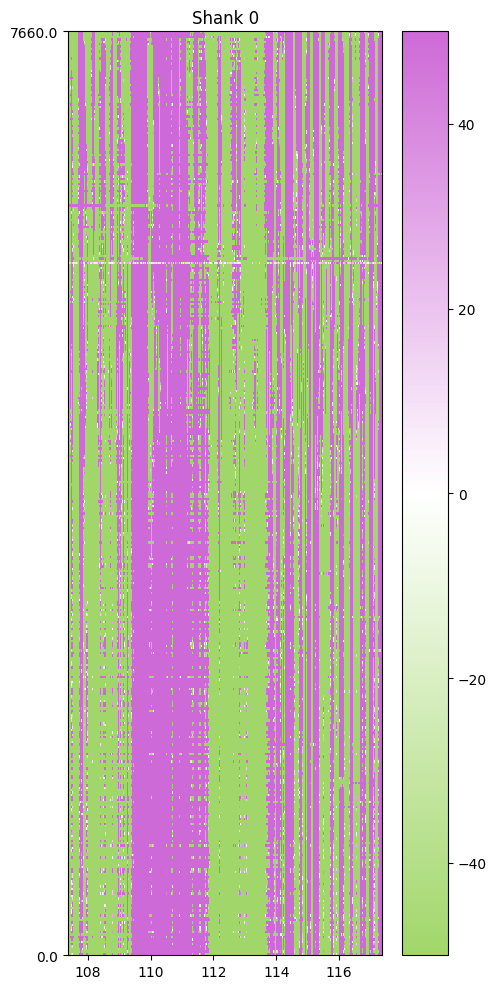

LFP figure saved → X:\Agata_spikesorted\20250311_Agata_VNS_N2_happy\2025-03-11_14-25-44\ProbeA\lfp\2025-03-11_14-25-44_ProbeA_LFP_traces.png
comment back this part after testing


KeyboardInterrupt: 

In [7]:
reRunKilosort       = False     # if True it will re-run kilosort even if the folder exists
reRunLFP            = False     # if True it will re-run LFP processing (filtering + resampling) even if shanks exist
replot_LFP          = False     # if True it will re-plot LFP figure even if it already exists
reRunAnalyzer       = False     # if True it will re-run sorting analyzer / phy export even if existing
reDoPreprocessing   = False     # if True it will re-run raw preprocessing even if existing
run_auto_curation   = False     # if True it will run SortingAnalyzer with auto-curation (metrics + ML classifiers)
min_duration        = 600       # minimum duration in seconds (10 minutes)
resampled_fs        = 1000      # target sampling frequency for LFP (after downsampling)
t_range_LFP         = (100, 110) # time range in seconds for LFP plotting (relative to the start of the recording)

for dataPath in folders2:
    # dataPath = r"I:\Neuropixels_Backup\Agata\20251219_Agata_VNS_N6_happy\2025-12-19_16-06-59" # for testing
    dataPath = os.path.normpath(dataPath)
    print(f"\nProcessing: {dataPath}")


    streams = si.get_neo_streams('openephysbinary', dataPath)
    stream_names, stream_ids = streams

    # Map streams per probe (NP1.0 has AP+LFP streams, NP2.0 typically only AP)
    probe_streams = {}
    for name, sid in zip(stream_names, stream_ids):
        m = re.search(r'Probe\w+', name)
        if not m:
            continue
        probe = m.group()
        entry = probe_streams.setdefault(probe, {'ap': None, 'lfp': None, 'other': []})
        lname = name.lower()
        if 'lfp' in lname:
            entry['lfp'] = sid
        elif 'ap' in lname or 'wideband' in lname:
            entry['ap'] = sid
        else:
            entry['other'].append(sid)

    for probe, entry in probe_streams.items():
        if entry['ap'] is None and entry['other']:
            entry['ap'] = entry['other'][0]

    probes = list(probe_streams.keys())
    print("Probes found:", probes)
    print("Streams by probe:", probe_streams)

    # -------------------------------
    # TTL Event extraction (once per recording, shared across probes)
    # -------------------------------
    parent_folder = os.path.basename(os.path.dirname(dataPath))
    subfolder = os.path.basename(dataPath)
    events_dest = os.path.join(dest_path, parent_folder, subfolder, 'events')
    os.makedirs(events_dest, exist_ok=True)

    events_OE = si.read_openephys_event(dataPath, block_index=0)
    first_ap_id = next((v['ap'] for v in probe_streams.values() if v['ap'] is not None), stream_ids[0])
    rec_t0    = si.read_openephys(dataPath, block_index=0, stream_id=first_ap_id)
    t0        = rec_t0.get_times(segment_index=0)[0]
    print(f"TTL channels : {events_OE.channel_ids}  |  t0 = {t0:.6f} s")

    ttl_ch_id   = events_OE.channel_ids[1]   # skip 'Messages' at index 0
    evs         = events_OE.get_events(channel_id=ttl_ch_id, segment_index=0)
    times_ttl   = np.array(evs['time'],  dtype=np.float64) - t0
    labels_ttl  = np.array(evs['label'], dtype=np.int16)

    ch_tag = ttl_ch_id.replace(' ', '_')
    np.save(os.path.join(events_dest, f"TTL_{ch_tag}_timestamps.npy"), times_ttl)
    np.save(os.path.join(events_dest, f"TTL_{ch_tag}_labels.npy"),     labels_ttl)
    print(f"Saved {len(times_ttl)} TTL events ('{ttl_ch_id}') → {events_dest}")

    for probe_name, stream_info in probe_streams.items():
        ap_id  = stream_info['ap']
        lfp_id = stream_info['lfp']
        if ap_id is None:
            print(f'  Skipping {probe_name}: no AP stream found')
            continue
        full_raw_rec            = si.read_openephys(dataPath, block_index=0, stream_id=ap_id)
        parent_folder = os.path.basename(os.path.dirname(dataPath))
        subfolder = os.path.basename(dataPath)
        dest_path_rec           = os.path.join(dest_path, parent_folder, subfolder, probe_name)
        if not os.path.exists(dest_path_rec):
            os.makedirs(dest_path_rec, exist_ok=True)

        fs                      = full_raw_rec.get_sampling_frequency()
        num_segments            = full_raw_rec.get_num_segments()
        durations               = [full_raw_rec.get_num_samples(seg) / fs for seg in range(num_segments)]
        print(f"Durations (s): {durations}")

        valid_segments = [seg for seg in range(num_segments)
                        if (full_raw_rec.get_num_samples(seg) / fs) >= min_duration]

        if not valid_segments:
            print(f"  Skipping: no segments ≥ {min_duration} s")
            continue

        full_raw_rec            = full_raw_rec.select_segments(valid_segments)
        fs                      = full_raw_rec.get_sampling_frequency()
        groups                  = full_raw_rec.get_property('group')
        Chan_IDs                = full_raw_rec.channel_ids
        num_chan                = full_raw_rec.get_num_channels()
        chan_pos                = full_raw_rec.get_channel_locations()
        recName                 = os.path.basename(os.path.normpath(dataPath))
        mainDir                 = os.path.basename(os.path.dirname(dataPath))
        dtype                   = full_raw_rec.get_dtype()
        gain_value              = full_raw_rec.get_channel_gains()    # µV per count
        offset_value            = full_raw_rec.get_channel_offsets()  # offset in µV

        print(full_raw_rec)

        probe                   = full_raw_rec.get_probe()
        if probe is None:
            print('WARNING: no probe geometry found in recording')
        else:
            try:
                recording_f = recording_f.set_probe(probe)
            except Exception as e:
                print(f'WARNING: could not attach probe to recording_f: {e}')
        pg                      = ProbeGroup()
        pg.add_probe(probe)
        probeNameKS             = recName + '_' + probe_name + '_KS.prb'
        probePathKS             = os.path.join(dest_path_rec, probeNameKS)
        write_prb(probePathKS, pg)

        probeNameSI             = recName + '_' + probe_name + '_SI.json'
        probePathSI             = os.path.join(dest_path_rec, probeNameSI)
        write_probeinterface(probePathSI, probe)


        # Select LFP stream if present (NP1.0), otherwise derive from AP (NP2.0)
        if lfp_id is not None:
            lfp_raw_rec = si.read_openephys(dataPath, block_index=0, stream_id=lfp_id)
        else:
            lfp_raw_rec = full_raw_rec

        # -------------------------------
        # LFP Processing
        # -------------------------------
        lfp_folder    = os.path.join(dest_path_rec, 'lfp')
        os.makedirs(lfp_folder, exist_ok=True)

        # I. Preprocess — no scale here, matching reference approach
        # Validate LFP segments and drop short ones (in case LFP is separate stream)
        lfp_fs = lfp_raw_rec.get_sampling_frequency()
        lfp_num_segments = lfp_raw_rec.get_num_segments()
        lfp_durations = [lfp_raw_rec.get_num_samples(seg) / lfp_fs for seg in range(lfp_num_segments)]
        lfp_valid_segments = [seg for seg in range(lfp_num_segments) if lfp_durations[seg] >= min_duration]
        if not lfp_valid_segments:
            print(f'  Skipping LFP: no segments ≥ {min_duration} s')
            continue
        
        lfp_raw_rec = lfp_raw_rec.select_segments(lfp_valid_segments)
        recording_shift = si.phase_shift(recording=lfp_raw_rec)
        si.set_global_job_kwargs(chunk_duration='20s')
        LFP_filtered    = si.bandpass_filter(
            recording_shift,
            freq_min=0.1,
            freq_max=300,
            ignore_low_freq_error=True,
        )
        downsample_LFP  = si.resample(LFP_filtered, resample_rate=resampled_fs)

        # II. Split by shank — NP2: split_by('group'); NP1: single shank
        lfp_groups = lfp_raw_rec.get_property('group')
        if lfp_groups is not None and len(np.unique(lfp_groups)) > 1:
            recordings_by_shank = downsample_LFP.split_by('group')
        else:
            recordings_by_shank = {0: downsample_LFP}

        shank_ids = list(recordings_by_shank.keys())
        if len(shank_ids) == 0:
            print('  Skipping LFP: no shanks available after segment filtering')
            continue
        n_shanks  = len(shank_ids)

        # Chunk size heuristic: NP1.0 (single shank / 384ch) needs smaller chunks for phase_shift FFT
        if n_shanks > 1:
            lfp_chunk_duration = '10s'
        else:
            lfp_chunk_duration = '2s'

        # III. Plot — all shanks side by side with GWPmap
        shank_ids = sorted(recordings_by_shank.keys())
        n_shanks  = len(shank_ids)

        fig_path = os.path.join(lfp_folder, f"{recName}_{probe_name}_LFP_traces.png")
        if replot_LFP or not os.path.exists(fig_path):
            LFP_fig, axs = plt.subplots(ncols=n_shanks, figsize=(5 * n_shanks, 10))
            if n_shanks == 1:
                axs = [axs]
            for ax, shank_id in zip(axs, shank_ids):
                rec = recordings_by_shank[shank_id]
                t0 = rec.get_times(segment_index=0)[0]  # absolute start time, the resampled rec may not start at 0
                
                if len(rec.channel_ids) == 0 or rec.get_num_samples() == 0:
                    print(f"Skipping empty shank {shank_id}")
                    continue
                si.plot_traces(rec,
                            time_range=(t0 + t_range_LFP[0], t0 + t_range_LFP[1]), # use this instead of time_range bacause the re-sampled recording may not start at 0
                            cmap=GWPmap,
                            order_channel_by_depth = True, 
                            backend='matplotlib',
                            clim=(-50,50),
                            ax=ax)
                ax.set_title(f"Shank {shank_id}")            
                plt.tight_layout()
                LFP_fig.savefig(fig_path, dpi=150)
                plt.show()
                print(f"LFP figure saved → {fig_path}")
        else:
            print(f"LFP figure already exists → {fig_path} (skipping plot)")

        # IV. Save — apply µV scale per shank at save time (avoids scale+split_by issue)
        # Check each shank individually for existence
        for shank_id, rec in recordings_by_shank.items():
            ch_mask      = np.isin(lfp_raw_rec.channel_ids, rec.channel_ids)
            shank_gain   = lfp_raw_rec.get_channel_gains()[ch_mask]
            shank_offset = lfp_raw_rec.get_channel_offsets()[ch_mask]
            rec_uv       = si.scale(rec, gain=shank_gain, offset=shank_offset, dtype='float32')
            shank_path   = os.path.join(lfp_folder, f"shank_{shank_id}")
            
            if reRunLFP or not os.path.isdir(shank_path) or not any(os.scandir(shank_path)):
                # rec_uv.save(folder=shank_path, format='binary', n_jobs=1, chunk_duration=lfp_chunk_duration, overwrite=True)
                # print(f"LFP shank {shank_id} saved → {shank_path}")
                print('comment back this part after testing')
            else:
                print(f"LFP shank {shank_id} already exists → {shank_path} (skipping save)")

        # -------------------------------
        # Spike-band preprocessing
        # -------------------------------
        recording_shift         = si.phase_shift(recording=full_raw_rec)
        recording_cmr           = si.common_reference(recording=recording_shift, operator="median")
        recording_f = si.bandpass_filter(
            recording=recording_cmr,
            freq_min=500,
            freq_max=6000
        )

        # -------------------------------
        # Detect periodic artifact periods by envelope and remove them
        # -------------------------------
        artifact_periods = detect_artifact_periods_by_envelope_manual(
            recording_f,
            threshold_std=7.0,
            min_distance_s=0.25,
            max_inspect_s=60.0,
            window_before_s=0.01,
            window_after_s=0.02,
            n_channels=32,
        )
        if len(artifact_periods) > 0:
            print(f"Detected {len(artifact_periods)} artifact periods")
            artifact_times = [start for start, stop in artifact_periods]
            recording_f_before = recording_f
            recording_f = remove_artifacts(
                recording=recording_f,
                list_triggers=artifact_times,
                ms_before=5.0,
                ms_after=15.0,
                mode='cubic'
            )

            # Visualize before / after around the first detected artifact
            first_start, first_stop = artifact_periods[0]
            window_pre  = max(0, first_start - 0.05)
            window_post = first_stop + 0.05
            fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
            si.plot_traces(
                recording_f_before,
                time_range=(window_pre, window_post),
                cmap=GWPmap,
                backend='matplotlib',
                ax=axs[0]
            )
            axs[0].set_title('Before artifact removal')
            si.plot_traces(
                recording_f,
                time_range=(window_pre, window_post),
                cmap=GWPmap,
                backend='matplotlib',
                ax=axs[1]
            )
            axs[1].set_title('After artifact removal')
            plt.tight_layout()
            plt.show()
        else:
            print('No artifact periods detected by envelope')

        # -------------------------------
        # 2️⃣ Define preprocessed folder (directly on destination drive)
        # -------------------------------
        preprocesseDir = os.path.join(dest_path_rec, 'preprocessed')
        os.makedirs(preprocesseDir, exist_ok=True)

        # -------------------------------
        # 3️⃣ Save or load binary recording
        # -------------------------------
        raw_files = [f for f in os.listdir(preprocesseDir) if f.endswith('.raw')]

        binary_dtype = "int16"

        do_preprocessing = reDoPreprocessing or (len(raw_files) == 0)

        if do_preprocessing:
            print("Running preprocessing (save raw binary)...")
            recording_to_save = si.astype(recording_f, dtype=binary_dtype)
            recording_saved = recording_to_save.save(
                folder=preprocesseDir,
                n_jobs=-1,
                chunk_duration='1s',
                overwrite=True
            )
        else:
            raw_file_path = os.path.join(preprocesseDir, raw_files[0])
            print(f"Loading existing preprocessed binary from {raw_file_path}")
            recording_saved = si.read_binary(
                raw_file_path,
                sampling_frequency=fs,
                num_channels=num_chan,
                dtype=binary_dtype,
                channel_ids=Chan_IDs,
                gain_to_uV=gain_value,
                offset_to_uV=offset_value
            )
            recording_saved = recording_saved.set_probe(probe)

        # Ensure probe geometry is attached for Kilosort/Phy
        if probe is not None:
            try:
                recording_saved = recording_saved.set_probe(probe)
            except Exception as e:
                print(f'WARNING: could not attach probe to recording_saved: {e}')

        # -------------------------------
        # 4️⃣ Kilosort4 via SpikeInterface
        # -------------------------------
        kilosort_folder = os.path.join(preprocesseDir, "kilosort4")
        sorter_output_spike_times = os.path.join(kilosort_folder, "sorter_output", "spike_times.npy")

        needs_rerun_kilosort = reRunKilosort or not os.path.exists(sorter_output_spike_times)

        if needs_rerun_kilosort:
            print(f"Running Kilosort4 (reRunKilosort={reRunKilosort})... ")
            sorting = si.run_sorter(
                sorter_name="kilosort4",
                recording=recording_saved,
                folder=kilosort_folder,
                remove_existing_folder=True,
                verbose=True,
                whitening_range=32,
                dminx=32,
                nblocks=5,
                do_CAR=False,
                )

            # kilosort writes binary.json in the preprocessed folder, not inside kilosort_folder
            binary_json_path = os.path.normpath(os.path.join(preprocesseDir, "binary.json"))
            if not os.path.exists(binary_json_path):
                raise FileNotFoundError(f"Expected binary.json not found at {binary_json_path} after run_sorter")

            if not os.path.exists(sorter_output_spike_times):
                raise FileNotFoundError(f"Expected spike_times.npy not found at {sorter_output_spike_times} after Kilosort")
        else:
            print(f"Skipping Kilosort: found existing sorter output with spike_times.npy")
            sorting = si.read_sorter_folder(kilosort_folder)

        # -------------------------------
        # 5️⃣ SortingAnalyzer for automated curation
        # -------------------------------
        if run_auto_curation:
            analyzer_folder = os.path.join(kilosort_folder, "analyzer")
            analyzer_export_folder = os.path.join(kilosort_folder, "analyzer_export")
            phy_folder      = os.path.join(kilosort_folder, "phy_export")

            os.makedirs(analyzer_folder, exist_ok=True)

            if reRunAnalyzer or not os.path.exists(os.path.join(analyzer_folder, "random_spikes.npz")):
                analyzer = si.create_sorting_analyzer(
                    sorting=sorting,
                    recording=recording_saved,
                    format="memory",
                    folder=analyzer_folder,
                    overwrite=True
                )
                analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=600, seed=2205)
                analyzer.compute("waveforms", ms_before=1.3, ms_after=2.6, n_jobs=-1)
                analyzer.compute("templates", operators=["average", "median", "std"])
                analyzer.compute("template_metrics", include_multi_channel_metrics=True)
                analyzer.compute("template_metrics", metric_names=["spread", "exp_decay", "velocity_above", "velocity_below"])
                analyzer.compute("principal_components", n_components=3, mode="by_channel_global", whiten=True, n_jobs=-1)
                exts = ['noise_levels','spike_locations','spike_amplitudes','correlograms','quality_metrics',
                                    'unit_locations','template_similarity']
                try:
                    analyzer.compute(exts, n_jobs=-1)
                except Exception as e:
                    print(f"Parallel compute failed, falling back to serial. Error: {repr(e)}")
                    analyzer.compute(exts, n_jobs=1)

        else:
            print(f"Skipping SortingAnalyzer and auto-curation (run_auto_curation={run_auto_curation})")

In [ ]:
# testing some stuff here
# recording_f = si.bandpass_filter(
#         recording=recording_cmr,
#         freq_min=500,
#         freq_max=6000
#     )

# -------------------------------
# Detect periodic artifact periods by envelope and remove them
# -------------------------------
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

crop_start = 13 * 60
crop_end   = 25 * 60
test_rec_raw = full_raw_rec.time_slice(start_time=crop_start, end_time=crop_end)
test_rec = si.phase_shift(test_rec_raw)

# IIR (sos) avoids the ~50 s FIR margin that causes memory blowup per chunk
test_rec = si.bandpass_filter(
    recording   = test_rec,
    freq_min    = 500,
    freq_max    = 6000,
    filter_mode = 'sos',
)

# ── Helper (module-level so joblib can pickle it) ─────────────────────────────
def _chunk_envelope(recording, start, end, channel_ids, segment_index):
    traces = recording.get_traces(
        segment_index = segment_index,
        start_frame   = start,
        end_frame     = end,
        channel_ids   = channel_ids,
    )
    return np.max(np.abs(traces), axis=1)

# ── Trigger detector: chunked, parallel, spatially subsampled ─────────────────
def detect_artifact_triggers(
    recording,
    threshold_std    = 7.0,
    channel_step     = 6,       # every Nth channel: 384 // 6 = 64, spatially uniform
    min_gap_s        = 0.05,
    chunk_duration_s = 30.0,
    n_jobs           = -1,
    segment_index    = 0,
):
    """
    Return (trigger_samples, threshold, envelope).
    trigger_samples : list[int]   local rising-edge sample index per event
    threshold       : float       absolute threshold (same units as traces)
    envelope        : 1-D ndarray max-abs across subsampled channels, full duration
    """
    fs          = recording.get_sampling_frequency()
    channel_ids = recording.channel_ids[::channel_step]
    num_samples = recording.get_num_samples(segment_index)
    chunk_size  = int(chunk_duration_s * fs)
    print(f"  Using {len(channel_ids)} / {recording.get_num_channels()} channels (every {channel_step}th)")

    chunk_ranges = [(s, min(s + chunk_size, num_samples))
                    for s in range(0, num_samples, chunk_size)]

    env_parts = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_chunk_envelope)(recording, s, e, channel_ids, segment_index)
        for s, e in tqdm(chunk_ranges, desc="Building envelope", unit="chunk")
    )
    envelope = np.concatenate(env_parts)

    # IQR-based robust spread — handles quantized int16 data where MAD → 0
    p50  = np.percentile(envelope, 50)
    p75  = np.percentile(envelope, 75)
    iqr  = (p75 - p50) / 0.6745                          # consistent with std for Gaussian
    floor = np.percentile(envelope, 1)                    # data-scale floor, avoids hard-coding 1.0
    threshold = p50 + threshold_std * max(iqr, floor)
    print(f"  p50={p50:.2f}  IQR-std={iqr:.4f}  threshold={threshold:.2f}  env-max={envelope.max():.2f}")

    above  = envelope > threshold
    edges  = np.where(~above[:-1] & above[1:])[0] + 1   # rising edges only

    min_gap  = int(min_gap_s * fs)
    triggers = []
    if len(edges):
        triggers = [int(edges[0])]
        for e in edges[1:]:
            if e - triggers[-1] > min_gap:
                triggers.append(int(e))

    return triggers, threshold, envelope

# ── Run ───────────────────────────────────────────────────────────────────────
THRESHOLD_STD = 7.0
MS_BEFORE     = 2.0
MS_AFTER      = 10.0

trigger_samples, threshold_val, envelope = detect_artifact_triggers(
    test_rec,
    threshold_std    = THRESHOLD_STD,
    channel_step     = 6,
    min_gap_s        = 0.05,
    chunk_duration_s = 30.0,
    n_jobs           = -1,
)

fs          = test_rec.get_sampling_frequency()
num_samples = test_rec.get_num_samples()

# trigger_samples are local (0 = first sample of crop).
# si.plot_traces expects global times because time_slice preserves the original time axis.
trigger_times_local_s  = [t / fs for t in trigger_samples]
trigger_times_global_s = [t + crop_start for t in trigger_times_local_s]

print(f"Detected {len(trigger_samples)} artifact triggers")

# Inter-event interval diagnostic
if len(trigger_times_global_s) > 1:
    ieis = np.diff(trigger_times_global_s)
    print(f"IEI — median: {np.median(ieis):.3f} s  min: {np.min(ieis):.3f} s  max: {np.max(ieis):.3f} s")
    fig_iei, ax_iei = plt.subplots(figsize=(8, 3))
    ax_iei.hist(ieis, bins=100)
    ax_iei.set_xlabel('Inter-event interval (s)')
    ax_iei.set_title('Distribution of gaps between detected triggers')
    plt.tight_layout()
    plt.show()

# ── Artifact removal ───────────────────────────────────────────────────────────
if len(trigger_samples) > 0:
    test_rec_before = test_rec
    test_rec_clean  = si.remove_artifacts(
        recording     = test_rec,
        list_triggers = trigger_samples,
        ms_before     = MS_BEFORE,
        ms_after      = MS_AFTER,
        mode          = 'cubic',
    )

    # ── Envelope plot (global time axis) ─────────────────────────────────────
    env_times = np.arange(len(envelope)) / fs + crop_start

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(env_times, envelope, lw=0.4, label='Envelope (max-abs, subsampled channels)')
    ax.axhline(threshold_val, color='orange', lw=1, linestyle='--',
               label=f'Threshold (×{THRESHOLD_STD} IQR-std)')
    for i, t_g in enumerate(trigger_times_global_s):
        ax.axvline(t_g, color='red', lw=0.8, alpha=0.6,
                   label='Trigger' if i == 0 else None)
    ax.set_title('Envelope with detected artifact triggers')
    ax.set_xlabel('Time (s, global)')
    ax.set_ylabel('Envelope amplitude')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Before / after traces around first artifact ───────────────────────────
    # si.plot_traces time_range must be in global time (recording axis starts at crop_start)
    first_t_global = trigger_times_global_s[0]
    window_pre     = max(float(crop_start), first_t_global - 0.05)
    window_post    = min(float(crop_end),   first_t_global + 0.15)

    # get_traces uses local frame indices
    frame_pre  = int((window_pre  - crop_start) * fs)
    frame_post = int((window_post - crop_start) * fs)
    chunk = test_rec_before.get_traces(start_frame=frame_pre, end_frame=frame_post)
    range2plt = float(np.percentile(np.abs(chunk), 95))

    fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    si.plot_traces(test_rec_before, time_range=(window_pre, window_post),
                   cmap=GWPmap, clim=(-range2plt, range2plt),
                   backend='matplotlib', ax=axs[0])
    axs[0].set_title('Before artifact removal')

    si.plot_traces(test_rec_clean, time_range=(window_pre, window_post),
                   cmap=GWPmap, clim=(-range2plt, range2plt),
                   backend='matplotlib', ax=axs[1])
    axs[1].set_title('After artifact removal')

    ms_b = MS_BEFORE / 1000
    ms_a = MS_AFTER  / 1000
    for t_g in trigger_times_global_s:
        if (t_g + ms_a) >= window_pre and (t_g - ms_b) <= window_post:
            for ax in axs:
                ax.axvspan(t_g - ms_b, t_g + ms_a, color='red', alpha=0.15)
                ax.axvline(t_g, color='red', lw=0.8, linestyle='--')

    plt.tight_layout()
    plt.show()

else:
    print('No artifact triggers detected — try lowering threshold_std')

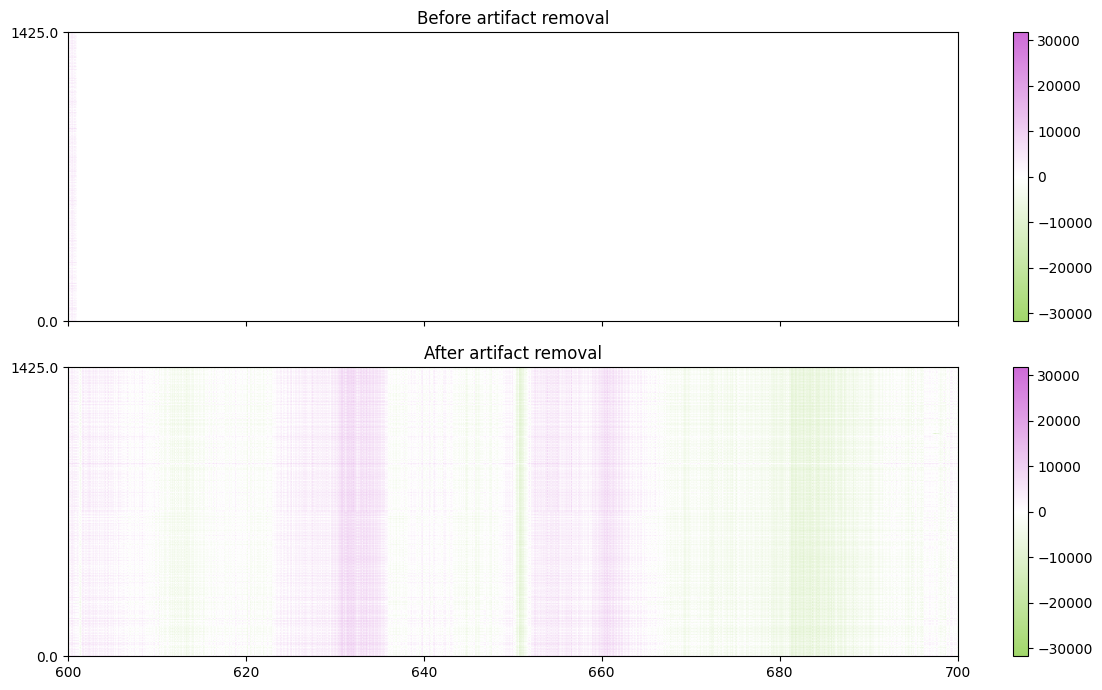

In [ ]:
crop_start = 600
crop_end = 700
test_rec_raw = full_raw_rec.time_slice(start_time=crop_start, end_time=crop_end)
test_rec = si.phase_shift(test_rec_raw)

chunk = test_rec.get_traces(
    start_frame=0,
    end_frame=test_rec.get_num_frames(),
)

MMax,mmin = np.percentile(np.abs(chunk), 5, 95)

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
si.plot_traces(
    test_rec,
    # time_range=(crop_start, crop_end),
    cmap=GWPmap,
    mode="map",
    clim=(-MMax, MMax),
    backend='matplotlib',
    ax=axs[0]
)
axs[0].set_title('Before artifact removal')
si.plot_traces(
    full_raw_rec,
    time_range=(crop_start, crop_end),
    mode="map",
    cmap=GWPmap,
    clim=(-MMax, MMax),
    backend='matplotlib',
    ax=axs[1]
)
axs[1].set_title('After artifact removal')

plt.tight_layout()
plt.show()

In [ ]:
import os
import spikeinterface as si

analyzer_folder = r"C:\tmp\spike_analyzer_cache"
os.makedirs(analyzer_folder, exist_ok=True)

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording_saved,
    folder=analyzer_folder,
    overwrite=True
)

# recompute your extensions
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=600, seed=2205)
analyzer.compute("waveforms", ms_before=1.3, ms_after=2.6, n_jobs=-1)
analyzer.compute("templates", operators=["average", "median", "std"])
analyzer.compute("template_metrics", include_multi_channel_metrics=True)
analyzer.compute("template_metrics", metric_names=["spread", "exp_decay", "velocity_above", "velocity_below"])
analyzer.compute("principal_components", n_components=3, mode="by_channel_global", whiten=True, n_jobs=-1)
# analyzer.compute(['noise_levels','spike_locations','spike_amplitudes','correlograms','quality_metrics',
#                 'unit_locations','template_similarity'],
#                 n_jobs=-1)
# run serial first to confirm it’s stable
analyzer.compute(
    ['noise_levels','spike_locations','spike_amplitudes','correlograms','quality_metrics',
     'unit_locations','template_similarity'],
    n_jobs=1
)


In [ ]:
# ── Raw trace overview per shank ───────────────────────────────────────────────
# Requires full_raw_rec to be in scope (run main loop first, or load manually).
# Splits by shank group and plots a short window with GWPmap colouring.

t_range_raw = [60, 62]   # seconds from recording start — adjust as needed
clim_raw    = (-100, 100) # µV limits for raw data — adjust to your signal

groups_raw = full_raw_rec.get_property('group')
if groups_raw is not None and len(np.unique(groups_raw)) > 1:
    recs_by_shank_raw = full_raw_rec.split_by('group')
else:
    recs_by_shank_raw = {0: full_raw_rec}

shank_ids_raw = list(recs_by_shank_raw.keys())
n_shanks_raw  = len(shank_ids_raw)

fig_raw, axs_raw = plt.subplots(ncols=n_shanks_raw, figsize=(5 * n_shanks_raw, 10))
if n_shanks_raw == 1:
    axs_raw = [axs_raw]

for ax, shank_id in zip(axs_raw, shank_ids_raw):
    rec = recs_by_shank_raw[shank_id]
    t0  = rec.get_times(segment_index=0)[0]  # absolute start time

    if len(rec.channel_ids) == 0 or rec.get_num_samples() == 0:
        print(f"Skipping empty shank {shank_id}")
        continue

    si.plot_traces(
        rec,
        time_range=(t0 + t_range_raw[0], t0 + t_range_raw[1]),
        cmap=GWPmap,
        backend='matplotlib',
        clim=clim_raw,
        ax=ax,
    )
    ax.set_title(f"Shank {shank_id}")

fig_raw.suptitle(f"Raw trace overview — {recName}  {probes[id_num]}", fontsize=11)
plt.tight_layout()
plt.show()

### Plot with ephyviewer

In [ ]:
# plot 5 seconds starting at 10 s
# w_ts = sw.plot_traces(full_raw_rec, mode="map", time_range=(5, 6), show_channel_ids=False, order_channel_by_depth=True)
# si.plot_traces(full_raw_rec, mode="map", time_range=(5, 6), show_channel_ids=False, order_channel_by_depth=True)
sig_source = ephyviewer.SpikeInterfaceRecordingSource(recording=recording_f)
app = ephyviewer.mkQApp()
win = ephyviewer.MainViewer(debug=True, show_auto_scale=True)

view = ephyviewer.TraceViewer(source=sig_source, name='signals')
win.add_view(view)
win.show() 
app.exec()